In [6]:
import pandas as pd
import pydicom as dicom
import numpy as np
import matplotlib.pyplot as plt
import skimage
import scipy

/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest-ZkhPvrLo5216730872708713142/CBIS-DDSM/Calc-Test_P_00038_LEFT_CC/08-29-2017-DDSM-NA-96009/1.000000-full mammogram images-63992/1-1.dcm


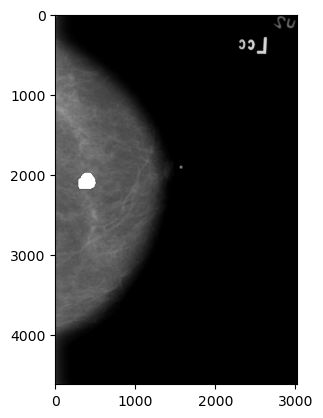

In [7]:
EXPORT_FILEPATH = "/media/gianluca/EXTERNAL_US/CBIS-DDSM"
lesions_df = pd.read_csv(f"{EXPORT_FILEPATH}/lesions.csv")

# histogram equalization
i = 0
subject_id = lesions_df.iloc()[i]["Subject ID"]
breast = lesions_df.iloc()[i]["breast"]
image_view = lesions_df.iloc()[i]["image view"]
fullimage_filepath = lesions_df.iloc()[i]["fullimage filepath"]
roi_mask_filepath = lesions_df.iloc()[i]["roi filepath"]

array = dicom.dcmread(fullimage_filepath).pixel_array
roi = dicom.dcmread(roi_mask_filepath).pixel_array

print(fullimage_filepath)
plt.imshow(array, cmap=plt.cm.grey)
plt.imshow(roi, cmap=plt.cm.grey, alpha =(roi>0).astype(float))

# Removal of labels

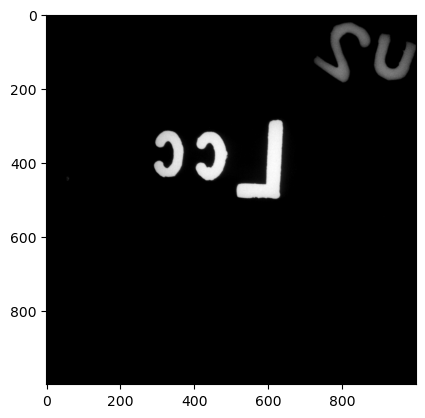

In [78]:
plt.imshow(array[0:1000, 2000:3000], cmap=plt.cm.grey)
plt.show()

# Application of filters and equalization

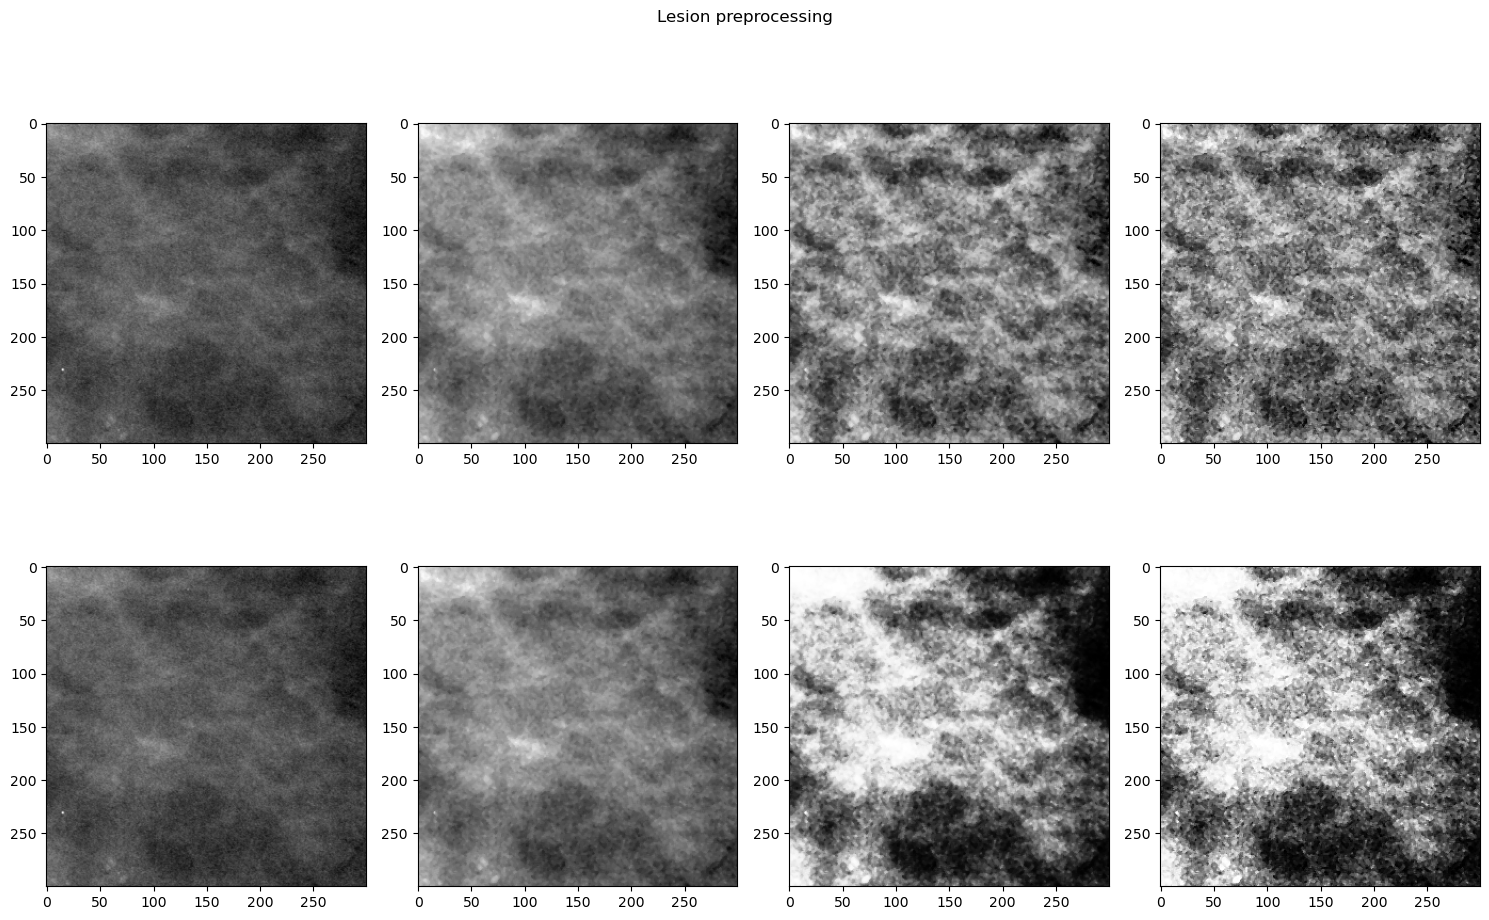

In [79]:
resized_array = array[1600:1900,350:650]

fig, ax = plt.subplots(2, 4, figsize=(15,10))
fig.suptitle('Lesion preprocessing')
ax[0,0].imshow(resized_array, cmap=plt.cm.grey)
ax[1,0].imshow(resized_array, cmap=plt.cm.grey)

# median filtering
median_filtered_array = scipy.ndimage.median_filter(resized_array, size=3)
ax[0,1].imshow(median_filtered_array, cmap=plt.cm.grey)
ax[1,1].imshow(median_filtered_array, cmap=plt.cm.grey)

# clahe and un sharp masking
clahe_array = skimage.exposure.equalize_adapthist(median_filtered_array)

ax[0,2].imshow(clahe_array, cmap=plt.cm.grey)
ax[0,3].imshow(skimage.filters.unsharp_mask(clahe_array), cmap=plt.cm.grey)

# histogram equalization and un sharp masking
equalized_hist_array = skimage.exposure.equalize_hist(median_filtered_array)
ax[1,2].imshow(equalized_hist_array, cmap=plt.cm.grey)
ax[1,3].imshow(skimage.filters.unsharp_mask(equalized_hist_array), cmap=plt.cm.grey)

fig.tight_layout()
plt.show()

# Cropping the ROI

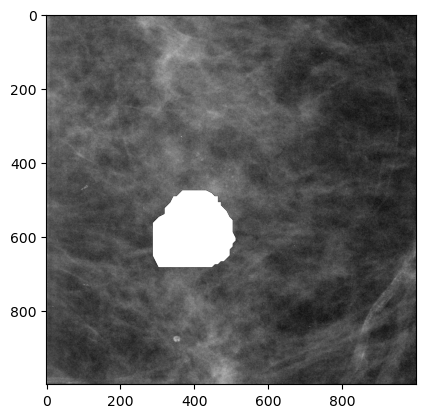

In [7]:
plt.imshow(array[1500:2500,0:1000], cmap=plt.cm.grey)
plt.imshow(roi[1500:2500,0:1000], cmap=plt.cm.grey, alpha =(roi[1500:2500,0:1000]>0).astype(float))

(1976, 2184, 288, 512)


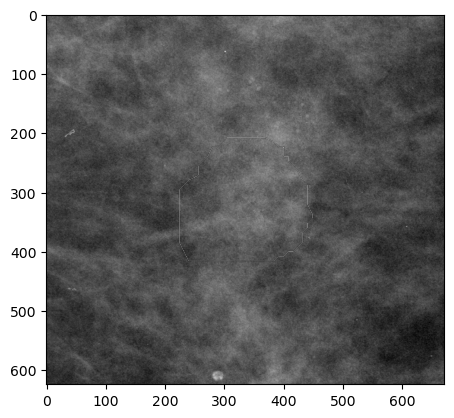

In [8]:
def get_contour(mask):
    # Shift mask in 4 directions (up, down, left, right)
    eroded = (
        mask & 
        np.roll(mask,  1, axis=0) & 
        np.roll(mask, -1, axis=0) & 
        np.roll(mask,  1, axis=1) & 
        np.roll(mask, -1, axis=1)
    )
    # Interior pixels become 0, leaving only the edge boundary
    return mask ^ eroded

# getting the bounding box around the roi
nonzero_coords = np.nonzero(roi)
lower_y, upper_y, lower_x, upper_x = min(nonzero_coords[0]), max(nonzero_coords[0]), min(nonzero_coords[1]), max(nonzero_coords[1])
print((lower_y, upper_y, lower_x, upper_x))

# enlarge by a 2 factor
y_offset = (upper_y - lower_y)*2
x_offset = (upper_x - lower_x)*2

plt.imshow(
    array[lower_y - int(y_offset/2):upper_y + int(y_offset/2), lower_x - int(x_offset/2):upper_x + int(x_offset/2)], 
    cmap=plt.cm.grey
)
contour_roi = get_contour(roi)
plt.imshow(
    contour_roi[lower_y - int(y_offset/2):upper_y + int(y_offset/2), lower_x - int(x_offset/2):upper_x + int(x_offset/2)], 
    cmap=plt.cm.grey, 
    alpha =(contour_roi[lower_y - int(y_offset/2):upper_y + int(y_offset/2), lower_x - int(x_offset/2):upper_x + int(x_offset/2)]>0).astype(float)
)

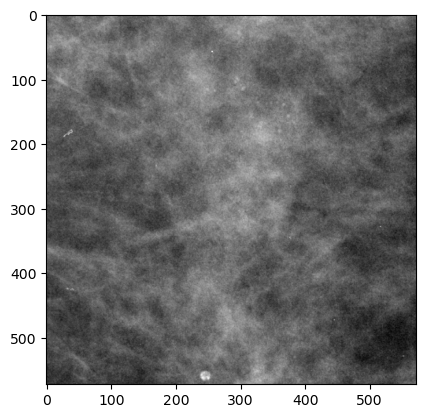

In [9]:
plt.imshow(skimage.transform.resize(array[lower_y - int(y_offset/2):upper_y + int(y_offset/2), lower_x - int(x_offset/2):upper_x + int(x_offset/2)], (572, 572)), cmap=plt.cm.grey)

In [97]:
import torch

def dice_loss(preds, targets, smooth=1e-6):
    """
    Dice = 2 x | A & B | / |A| + |B|
    
    :param preds: tensor of predictions (dims)
    :param targets: tensor of targets (dims)
    """
    # sigmoid maps unbounded numbers to continous probability range [0,1]
    sigmoid_preds = torch.sigmoid(preds)

    sigmoid_preds = sigmoid_preds.contiguous().view(-1)
    targets = targets.contiguous().view(-1)
    
    intersection = (sigmoid_preds * targets).sum()
    union = sigmoid_preds.sum() + targets.sum()
    dice = (2. * intersection + smooth) / (union + smooth)
    return 1.0 - dice

In [107]:
mask = np.array([[-100,-100,-100],[-100,-100,-100],[-100,-100,10]])
target_mask = np.array([[0,0,0],[0,0,0],[0,0,1]])

In [108]:
torch.sigmoid(torch.from_numpy(mask))

tensor([[0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 1.0000]])

In [109]:
target_mask

array([[0, 0, 0],
       [0, 0, 0],
       [0, 0, 1]])

In [110]:
dice_loss(
    torch.from_numpy(mask),
    torch.from_numpy(inverted_mask)
)

tensor(2.2709e-05)

# Wrapping up

In [11]:
array.shape

(4616, 3016)

In [12]:
roi.shape

(4616, 3016)

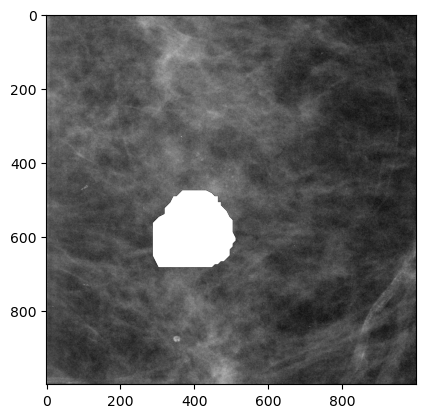

In [17]:
plt.imshow(array[1500:2500,0:1000], cmap=plt.cm.grey)
plt.imshow(roi[1500:2500,0:1000], cmap=plt.cm.grey, alpha =(roi[1500:2500,0:1000]>0).astype(float))

In [28]:
def preprocess(image: np.array, mask: np.array, enlarging_factor: int = 2) -> tuple:
    ## Preprocess the image
    # application of median filtering
    median_filtered_image = scipy.ndimage.median_filter(image, size=3)

    # application of clahe
    clahe_image = skimage.exposure.equalize_adapthist(median_filtered_image)
    
    # application of unsharp
    preproc_image = skimage.filters.unsharp_mask(clahe_image)

    ## Preprocess the mask
    # getting the bounding box around the roi
    nonzero_coords = np.nonzero(mask)
    lower_y, upper_y, lower_x, upper_x = min(nonzero_coords[0]), max(nonzero_coords[0]), min(nonzero_coords[1]), max(nonzero_coords[1])
    
    # enlarge by a 2 factor
    y_offset = (upper_y - lower_y)*enlarging_factor
    x_offset = (upper_x - lower_x)*enlarging_factor

    # Shrink bot the image and the mask
    preproc_image = preproc_image[lower_y - int(y_offset/2):upper_y + int(y_offset/2), lower_x - int(x_offset/2):upper_x + int(x_offset/2)]
    preproc_mask = mask[lower_y - int(y_offset/2):upper_y + int(y_offset/2), lower_x - int(x_offset/2):upper_x + int(x_offset/2)]
    print(preproc_image.shape)
    
    TARGET_SHAPE = (572, 572)
    preproc_image = skimage.transform.resize(preproc_image, TARGET_SHAPE) # downscales the image
    preproc_mask = skimage.transform.resize(preproc_mask, TARGET_SHAPE)
    return preproc_image, preproc_mask

In [29]:
preprocessed_array, preprocessed_roi = preprocess(array, roi)

(624, 672)


In [30]:
preprocessed_array.shape

(572, 572)

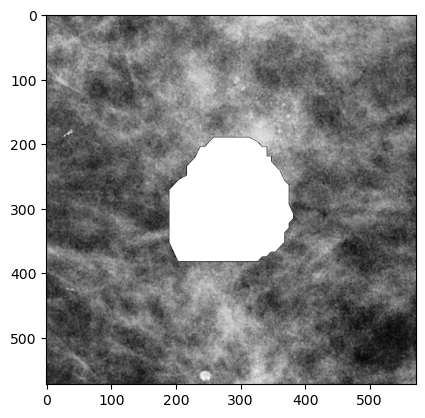

In [31]:
plt.imshow(preprocessed_array, cmap=plt.cm.grey)
plt.imshow(preprocessed_roi, cmap=plt.cm.grey, alpha =(preprocessed_roi>0).astype(float))